# Milestone_3



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("flights_new.csv")

df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,distance,hour,minute,time_hour,name,flight_date,day_of_week,route,cancelled,on_time
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,EWR-IAH,0,0
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.,2013-01-01,Tuesday,LGA-IAH,0,0
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.,2013-01-01,Tuesday,JFK-MIA,0,0
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,1576,5,45,2013-01-01 05:00:00,JetBlue Airways,2013-01-01,Tuesday,JFK-BQN,0,1
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.,2013-01-01,Tuesday,LGA-ATL,0,1


# Top 10 Origin–Destination Routes

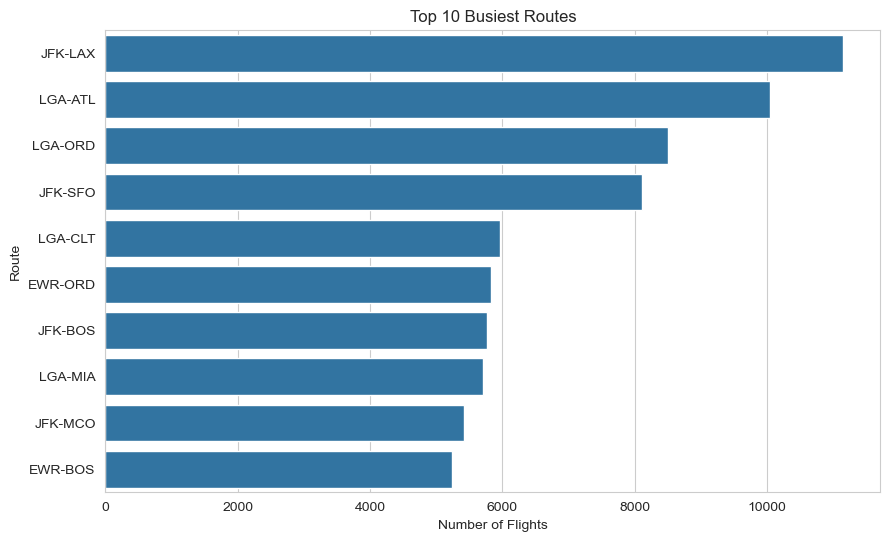

In [3]:
top_routes = df['route'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_routes.values,
    y=top_routes.index
)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

# Routes with Highest Average Delay

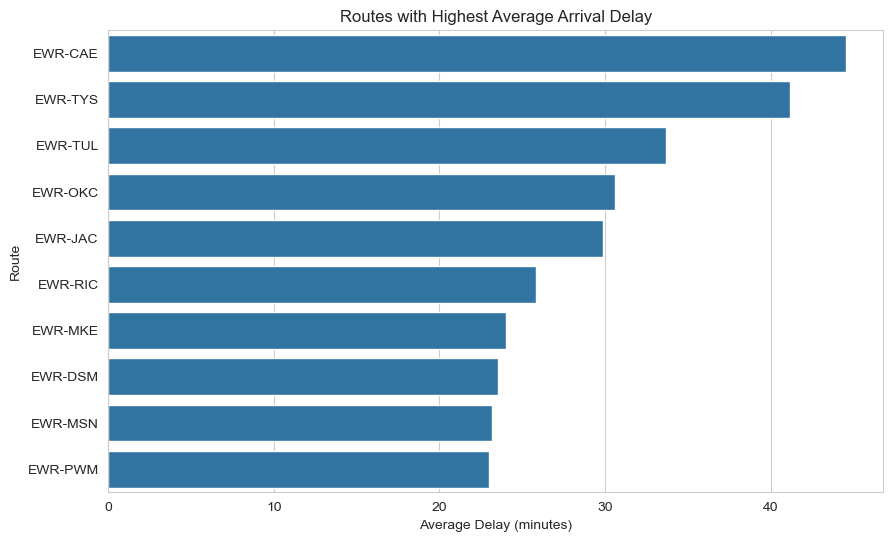

In [4]:
route_delay = (
    df.groupby('route')['arr_delay']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=route_delay.values,
    y=route_delay.index
)

plt.title("Routes with Highest Average Arrival Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Route")

plt.show()

# Delay Heatmap by Route

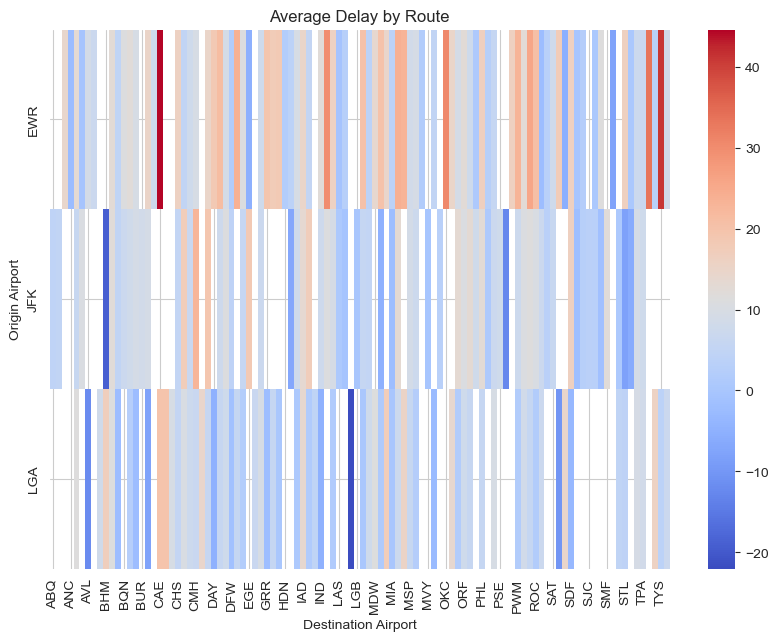

In [5]:
pivot_route = df.pivot_table(
    values='arr_delay',
    index='origin',
    columns='dest',
    aggfunc='mean'
)

plt.figure(figsize=(10,7))

sns.heatmap(
    pivot_route,
    cmap="coolwarm"
)

plt.title("Average Delay by Route")
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.show()

# Winter vs Non-Winter Delay Comparison

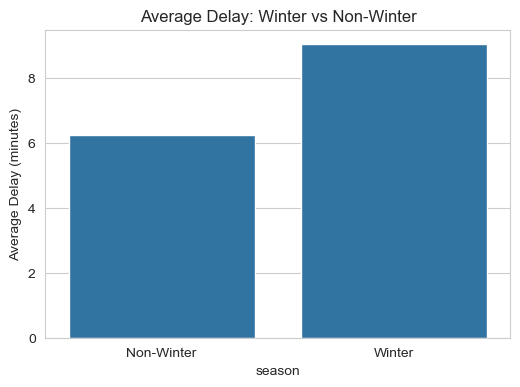

In [11]:
winter_months = [12,1,2]

df['season'] = df['month'].apply(
    lambda x: 'Winter' if x in winter_months else 'Non-Winter'
)

season_delay = df.groupby('season')['arr_delay'].mean().reset_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x='season',
    y='arr_delay',
    data=season_delay
)

plt.title("Average Delay: Winter vs Non-Winter")
plt.ylabel("Average Delay (minutes)")

plt.show()

# Seasonal Delay Heatmap

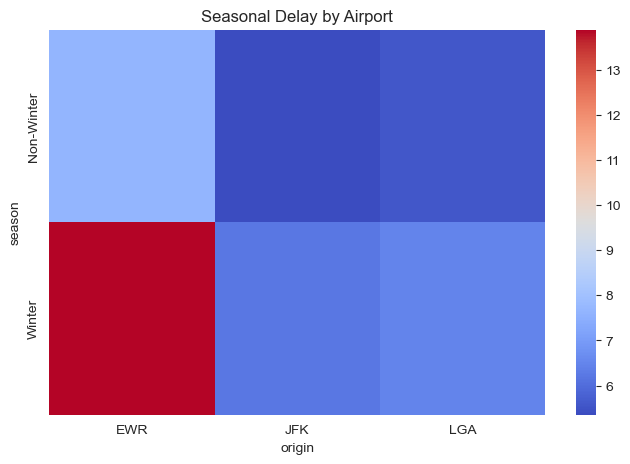

In [12]:
pivot_season = df.pivot_table(
    values='arr_delay',
    index='season',
    columns='origin',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_season,
    cmap="coolwarm"
)

plt.title("Seasonal Delay by Airport")

plt.show()